In [13]:
# ==================== CELL 1: SETUP ====================
# !pip install -q sentence-transformers scikit-learn matplotlib seaborn pandas numpy

import torch
import numpy as np
import pandas as pd
import time
import itertools
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported")
print("Device:", "GPU" if torch.cuda.is_available() else "CPU")

All libraries imported
Device: GPU


In [14]:
# ==================== CELL 2: LOAD MODEL ====================
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"Model loaded — embedding dim: {model.get_sentence_embedding_dimension()}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded — embedding dim: 384


In [15]:
# ==================== CELL 3: VOCABULARY ====================
# Shared vocabulary used by the combinatorial generator

COLORS   = ["red", "blue", "green", "yellow", "orange"]
OBJECTS  = ["cube", "block", "sphere", "ball", "cylinder", "bottle"]
LOCS     = ["table", "left side", "right side", "center", "shelf", "corner"]
PREFIXES = ["", "please ", "carefully "]   # only safe ones (similarity > 0.90 confirmed)

In [16]:
# ==================== CELL 4: MANUAL SEED DATA ====================
# 25 hand-written natural sentences per type (Elbatoul's 5 + new 5)
# These give the dataset realism and natural phrasing variation.

manual_data = {

    # ── EXISTING 5 TYPES (25 each, Elbatoul's natural sentences) ──────────────

    "pick": [
        "pick the red block",
        "grab the blue cube",
        "lift the green sphere",
        "take the red ball from the shelf",
        "get the small red cube",
        "retrieve the blue block on the left",
        "collect the green object near the wall",
        "fetch the red sphere from the corner",
        "can you pick up the red ball?",
        "please grab the blue sphere",
        "I need you to lift the green block",
        "pick up the blue cube on the floor",
        "take the green block from the table",
        "grab the large green block",
        "lift the red sphere gently",
        "get me the blue object near the edge",
        "grab whichever block is blue",
        "pick the large red object",
        "lift the green ball near the wall",
        "take the blue block on the left",
        "grab the red cube carefully",
        "pick the blue object on the right",
        "lift the small green sphere",
        "get the green cube near the edge",
        "pick up the small blue ball",
    ],

    "push": [
        "push the red block forward",
        "slide the blue cube to the right",
        "shove the green sphere aside",
        "nudge the red ball toward the wall",
        "knock the blue block to the left",
        "roll the green ball to the corner",
        "push the green sphere away",
        "slide the blue sphere forward gently",
        "give the blue cube a gentle push",
        "shove the red sphere aside",
        "push the red cube away from you",
        "slide the red ball to the left",
        "push the large green block forward",
        "give the blue block a push",
        "shove the green cube to the left",
        "slide the blue object to the right side",
        "push the green ball toward the edge",
        "push the small green cube aside",
        "push the red block to the right side",
        "shove the red object toward the wall",
        "slide the red object toward the box",
        "nudge the green block a little to the right",
        "roll the red ball away from the edge",
        "push the blue ball to the corner",
        "push the blue sphere gently forward",
    ],

    "move": [
        "move to the table",
        "go to the left side",
        "navigate to the right side",
        "head to the center carefully",
        "travel to the far end of the table",
        "approach the left corner",
        "reposition yourself to the right side",
        "move the arm to home position",
        "go to the center of the scene",
        "move closer to the wall",
        "head to the right side",
        "navigate to the left corner",
        "move toward the center",
        "go to the far end",
        "head toward the right corner",
        "move to where the red block is",
        "go near the blue object",
        "move toward the box",
        "go to the edge of the table",
        "move to the near side",
        "go to the left end of the table",
        "approach the table slowly",
        "travel to the right end",
        "reposition to the center of the workspace",
        "move the arm to the table",
    ],

    "put": [
        "put the green cube on the left side",
        "put the red block on the table",
        "set the red ball on the shelf",
        "drop the red cube on the table",
        "lay the blue block flat on the surface",
        "rest the green sphere on the right side",
        "leave the red block near the edge",
        "deposit the blue cube on the left side",
        "put the blue object down carefully",
        "put the blue cube next to the wall",
        "place the green cube inside the container",
        "set the red block near the edge",
        "place the green cube to the left",
        "set the green sphere down gently",
        "set the red object down on the right",
        "put the small blue block on top",
        "put the blue sphere inside the box",
        "place the green block on the right side",
        "place the blue cube in the box",
        "drop the red sphere on the left side",
        "drop the red object near the wall",
        "place the green object on the shelf",
        "put the blue block on the table please",
        "put the blue sphere on top of the box",
        "place the green sphere on the floor",
    ],

    "find": [
        "find the red block",
        "locate the green ball near the edge",
        "look for the green sphere",
        "search for the blue object",
        "spot the red cube on the table",
        "scan for the green block nearby",
        "identify the blue sphere in the scene",
        "detect the red object near the wall",
        "recognize the green cube on the left",
        "where is the blue cube?",
        "where is the large green cube?",
        "where is the small blue block?",
        "can you locate the red ball?",
        "can you find the blue cube?",
        "can you spot the green sphere?",
        "find the green object near the wall",
        "find the small blue sphere",
        "find whichever object is green",
        "look for the red block on the right",
        "look for the red sphere on the left",
        "search for the red cube on the floor",
        "search for the green block nearby",
        "find the blue object near the corner",
        "locate the red cube on the table",
        "locate the red object on the shelf",
    ],

    # ── NEW 5 TYPES (25 each, hand-written) ───────────────────────────────────

    "stack": [
        "stack the red cube on the blue block",
        "place the green sphere on top of the red cube",
        "put the blue block on top of the green sphere",
        "stack the yellow cube on the red block",
        "pile the green block on top of the blue cube",
        "place the orange sphere on top of the yellow block",
        "stack the blue cylinder on the green cube",
        "put the red ball on top of the blue cylinder",
        "place the green block on top of the red ball",
        "stack the blue cube on the orange block",
        "pile the red sphere on top of the blue block",
        "put the green cylinder on top of the red sphere",
        "stack the yellow block on the green cylinder",
        "place the red cube on top of the yellow block",
        "put the blue sphere on top of the red cube",
        "stack the green block on the blue sphere",
        "place the orange cube on top of the green block",
        "put the red cylinder on top of the orange cube",
        "stack the blue block on the red cylinder",
        "pile the green cube on top of the blue block",
        "place the yellow sphere on top of the green cube",
        "stack the red block on the yellow sphere",
        "put the blue cube on top of the red block",
        "place the green sphere on the blue cube",
        "stack the orange block on top of the green sphere",
    ],

    "sort": [
        "sort the blocks by color",
        "group the red objects together",
        "separate the blue cubes from the green ones",
        "arrange the objects by size",
        "organize the spheres on the left and cubes on the right",
        "sort all red objects to the left side",
        "group all blue objects near the wall",
        "separate the large objects from the small ones",
        "arrange the blocks in a row by color",
        "sort the cylinders away from the spheres",
        "group the green objects on the shelf",
        "separate all cubes from all balls",
        "organize the objects by shape",
        "sort the yellow objects to the right side",
        "group all small objects to the corner",
        "arrange all large blocks on the left",
        "sort the orange objects near the edge",
        "group the spheres together on the table",
        "separate the red blocks from the blue blocks",
        "organize the objects from smallest to largest",
        "sort all cylinders to the right side",
        "group all balls together near the center",
        "separate green objects from yellow objects",
        "arrange the cubes in order by color",
        "sort all objects by shape into groups",
    ],

    "avoid": [
        "move to the table without hitting the red block",
        "go to the left side while avoiding the blue cube",
        "navigate to the shelf without touching anything",
        "approach the center while avoiding the green sphere",
        "move to the right side without knocking objects over",
        "go to the corner while avoiding the yellow block",
        "navigate around the red cube to reach the table",
        "approach the shelf without disturbing the blue ball",
        "move to the left while avoiding all obstacles",
        "go to the center carefully avoiding the red sphere",
        "navigate to the right corner without touching objects",
        "approach the edge while avoiding the green block",
        "move toward the wall without hitting anything",
        "go to the shelf while keeping distance from blue objects",
        "navigate around the obstacles to reach the left side",
        "approach the table without disturbing the red cube",
        "move to the corner avoiding the orange block",
        "go to the right while keeping clear of the sphere",
        "navigate to the center without touching the yellow cube",
        "approach the left corner while avoiding the green ball",
        "move to the far end without hitting any objects",
        "go to the shelf without knocking over the blue block",
        "navigate around the red sphere to the right side",
        "approach the center while avoiding the orange cylinder",
        "move to the table carefully avoiding all obstacles",
    ],

    "rotate": [
        "rotate the red cube 90 degrees",
        "turn the blue block to face left",
        "spin the green sphere around",
        "rotate the yellow cylinder clockwise",
        "flip the red block upside down",
        "turn the blue cube to face right",
        "rotate the green block 180 degrees",
        "spin the orange sphere counterclockwise",
        "flip the yellow cube on its side",
        "rotate the red cylinder 45 degrees",
        "turn the blue sphere to face the wall",
        "rotate the green cube to the left",
        "spin the red block clockwise",
        "flip the blue cylinder horizontally",
        "rotate the orange block 90 degrees clockwise",
        "turn the green sphere to face right",
        "rotate the yellow block counterclockwise",
        "spin the red cube to face left",
        "flip the blue block to its other side",
        "rotate the green cylinder 180 degrees",
        "turn the orange cube 90 degrees to the right",
        "rotate the red sphere clockwise",
        "spin the blue block counterclockwise",
        "flip the green cube upside down",
        "rotate the yellow sphere 45 degrees",
    ],

    "reset": [
        "reset the arm to home position",
        "return everything to the starting position",
        "put all objects back where they started",
        "reset the scene",
        "bring the arm back to neutral",
        "restore all objects to their original positions",
        "return the arm to rest position",
        "reset all blocks to starting layout",
        "go back to the initial configuration",
        "put everything back to start",
        "return to home position",
        "reset the workspace to initial state",
        "bring everything back to the beginning",
        "restore the arm to neutral position",
        "put the arm back to home",
        "reset the environment",
        "return all objects to where they were",
        "go back to the default position",
        "restore the scene to initial layout",
        "bring the arm back to zero position",
        "reset to starting state",
        "return the workspace to default",
        "put everything back to its original place",
        "restore the arm to starting position",
        "reset all objects and arm to initial positions",
    ],
}

In [17]:
# ==================== CELL 5: COMBINATORIAL GENERATOR ====================
# Generates ~40 additional unique instructions per type using template × vocab

def generate_combinatorial(cmd_type, existing, target=40):
    """Generate unique instructions not already in `existing`."""
    generated = []
    existing_set = set(existing)

    templates = {
        "pick": [
            "{prefix}pick the {color} {obj}",
            "{prefix}grab the {color} {obj}",
            "{prefix}lift the {color} {obj}",
            "{prefix}take the {color} {obj}",
            "{prefix}get the {color} {obj}",
        ],
        "push": [
            "{prefix}push the {color} {obj} to the {loc}",
            "{prefix}slide the {color} {obj} to the {loc}",
            "{prefix}nudge the {color} {obj} toward the {loc}",
            "{prefix}shove the {color} {obj} to the {loc}",
        ],
        "move": [
            "{prefix}move to the {loc}",
            "{prefix}go to the {loc}",
            "{prefix}navigate to the {loc}",
            "{prefix}head to the {loc}",
            "{prefix}approach the {loc}",
        ],
        "put": [
            "{prefix}place the {color} {obj} on the {loc}",
            "{prefix}put the {color} {obj} on the {loc}",
            "{prefix}set the {color} {obj} on the {loc}",
            "{prefix}drop the {color} {obj} on the {loc}",
        ],
        "find": [
            "{prefix}find the {color} {obj}",
            "{prefix}locate the {color} {obj}",
            "{prefix}identify the {color} {obj}",
            "{prefix}search for the {color} {obj}",
            "{prefix}spot the {color} {obj}",
        ],
        "stack": [
            "{prefix}stack the {color} {obj} on the {color2} {obj2}",
            "{prefix}place the {color} {obj} on top of the {color2} {obj2}",
            "{prefix}put the {color} {obj} on top of the {color2} {obj2}",
        ],
        "sort": [
            "{prefix}sort the {color} objects to the {loc}",
            "{prefix}group all {color} {obj}s together",
            "{prefix}separate the {color} {obj}s from the rest",
            "{prefix}arrange the {color} objects on the {loc}",
        ],
        "avoid": [
            "{prefix}move to the {loc} avoiding the {color} {obj}",
            "{prefix}go to the {loc} without touching the {color} {obj}",
            "{prefix}navigate to the {loc} while avoiding the {color} {obj}",
        ],
        "rotate": [
            "{prefix}rotate the {color} {obj} clockwise",
            "{prefix}rotate the {color} {obj} counterclockwise",
            "{prefix}turn the {color} {obj} 90 degrees",
            "{prefix}flip the {color} {obj} to the {loc}",
            "{prefix}spin the {color} {obj} around",
        ],
        "reset": [
            "{prefix}reset the {color} {obj} to start",
            "{prefix}return the {color} {obj} to its original position",
            "{prefix}put the {color} {obj} back to start",
            "{prefix}restore the {color} {obj} to initial position",
        ],
    }

    tmpls = templates.get(cmd_type, [])
    combos = list(itertools.product(PREFIXES, COLORS, OBJECTS, LOCS, COLORS, OBJECTS))

    for prefix, color, obj, loc, color2, obj2 in combos:
        if len(generated) >= target:
            break
        for tmpl in tmpls:
            try:
                text = tmpl.format(
                    prefix=prefix, color=color, obj=obj,
                    loc=loc, color2=color2, obj2=obj2
                ).strip()
            except KeyError:
                continue
            if text not in existing_set and text not in generated:
                generated.append(text)
                existing_set.add(text)
            if len(generated) >= target:
                break

    return generated[:target]

In [18]:
# ==================== CELL 6: BUILD FULL DATASET ====================

TARGET_PER_TYPE = 50
all_rows = []

print(f"{'Type':<10} {'Manual':>8} {'Generated':>10} {'Total':>7}")
print("-" * 38)

for cmd_type, manual_sentences in manual_data.items():
    manual_count = len(manual_sentences)
    needed = TARGET_PER_TYPE - manual_count
    generated = generate_combinatorial(cmd_type, manual_sentences, target=needed)

    for s in manual_sentences:
        all_rows.append({"instruction": s, "type": cmd_type, "source": "manual"})
    for s in generated:
        all_rows.append({"instruction": s, "type": cmd_type, "source": "generated"})

    print(f"{cmd_type:<10} {manual_count:>8} {len(generated):>10} {manual_count+len(generated):>7}")

df = pd.DataFrame(all_rows)
df = df.drop_duplicates(subset=["instruction"]).reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nFinal dataset: {len(df)} instructions across {df['type'].nunique()} types")
print(df["type"].value_counts().to_string())

Type         Manual  Generated   Total
--------------------------------------
pick             25         25      50
push             25         25      50
move             25         25      50
put              25         25      50
find             25         25      50
stack            25         25      50
sort             25         25      50
avoid            25         25      50
rotate           25         25      50
reset            25         25      50

Final dataset: 500 instructions across 10 types
type
avoid     50
push      50
put       50
move      50
reset     50
pick      50
rotate    50
sort      50
stack     50
find      50


In [19]:
# ==================== CELL 7: ENCODE + CACHE ====================

print("\nEncoding all instructions...")
t_start = time.perf_counter()
embeddings_np = model.encode(
    df["instruction"].tolist(),
    convert_to_tensor=False,
    show_progress_bar=True,
    batch_size=64
)
t_encode = time.perf_counter() - t_start

df["embedding"] = list(embeddings_np)
X = embeddings_np

print(f"\n✅ Encoded {len(df)} instructions in {t_encode:.2f}s")
print(f"   Embedding matrix shape: {X.shape}  (expected: ({len(df)}, 384))")

# Save outputs
df[["instruction", "type", "source"]].to_csv("nlp_instructions_500.csv", index=False)
df.to_pickle("nlp_instructions_500_with_embeddings.pkl")
np.save("embeddings_500.npy", embeddings_np)
print("✅ Saved: nlp_instructions_500.csv / .pkl / embeddings_500.npy")


Encoding all instructions...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]


✅ Encoded 500 instructions in 0.24s
   Embedding matrix shape: (500, 384)  (expected: (500, 384))
✅ Saved: nlp_instructions_500.csv / .pkl / embeddings_500.npy


In [20]:
# ==================== CELL 8: ONE-LINE CACHE ====================

embedding_cache = {row["instruction"]: np.array(row["embedding"]) for _, row in df.iterrows()}

def get_embedding(instruction: str) -> np.ndarray:
    """Return cached embedding or encode on the fly."""
    if instruction in embedding_cache:
        return embedding_cache[instruction]
    return model.encode([instruction])[0]

# Speed test — cached
times = [
    (lambda t0: (time.perf_counter() - t0) * 1000)(time.perf_counter())
    or (time.perf_counter() - (lambda: time.perf_counter())()) * 1000
    for _ in range(20)
]
# Cleaner version:
times = []
for _ in range(20):
    t0 = time.perf_counter()
    _ = get_embedding("pick the red block")
    times.append((time.perf_counter() - t0) * 1000)

avg_ms = np.mean(times)
status = "✅ PASS" if avg_ms < 10 else "❌ SLOW"
print(f"\n{status} — Cached lookup: {avg_ms:.3f}ms  (target: <10ms)")
print("\n# RL team loads embeddings in one line:")
print("# embeddings = np.load('embeddings_500.npy')")
print("# df = pd.read_pickle('nlp_instructions_500_with_embeddings.pkl')")



✅ PASS — Cached lookup: 0.002ms  (target: <10ms)

# RL team loads embeddings in one line:
# embeddings = np.load('embeddings_500.npy')
# df = pd.read_pickle('nlp_instructions_500_with_embeddings.pkl')


In [21]:
# ==================== CELL 9: PARAPHRASE SIMILARITY ====================
# Tests that same-intent pairs are close (>0.85 strict, >0.75 soft)

same_intent_pairs = [
    # pick
    ("pick the red cube",              "grab the red cube"),
    ("lift the blue block",            "take the blue block"),
    # push
    ("push the blue cube to the right","slide the blue cube to the right"),
    ("shove the red block forward",    "push the red block forward"),
    # move
    ("move to the left side",          "go to the left side"),
    ("head to the table",              "navigate to the table"),
    # put
    ("put the red block on the table", "place the red block on the table"),
    ("set the blue cube down",         "put the blue cube down"),
    # find
    ("find the green sphere",          "look for the green sphere"),
    ("locate the blue cube",           "search for the blue cube"),
    # stack
    ("stack the red cube on the blue block", "place the red cube on top of the blue block"),
    ("put the green sphere on top of the red cube", "stack the green sphere on the red cube"),
    # sort
    ("sort the red objects to the left side", "group all red objects on the left"),
    ("separate the blue cubes from the rest", "sort the blue cubes away from the others"),
    # avoid
    ("move to the table avoiding the red block", "go to the table without touching the red block"),
    # rotate
    ("rotate the red cube clockwise",  "turn the red cube clockwise"),
    ("spin the blue sphere around",    "rotate the blue sphere around"),
    # reset
    ("reset the arm to home position", "return the arm to rest position"),
    ("put everything back to start",   "restore the scene to initial layout"),
]

cross_class_pairs = [
    ("pick the red block",              "move to the table"),
    ("push the blue cube forward",      "find the green sphere"),
    ("put the red block on the table",  "go to the left side"),
    ("stack the red cube on the blue",  "sort the objects by color"),
    ("rotate the green cylinder",       "reset the arm to home"),
    ("avoid the red block",             "pick the blue cube"),
]

STRICT = 0.85
SOFT   = 0.75
CROSS  = 0.50

print("── SAME-INTENT pairs (target > 0.85 strict / > 0.75 soft) ──")
strict_pass = soft_pass = 0
for a, b in same_intent_pairs:
    ea, eb = model.encode([a])[0], model.encode([b])[0]
    sim = cosine_similarity([ea], [eb])[0][0]
    strict = sim >= STRICT
    soft   = sim >= SOFT
    strict_pass += strict
    soft_pass   += soft
    tag = "strict" if strict else ("soft  " if soft else "fail  ")
    print(f"  {tag} {sim:.4f} | '{a}' ↔ '{b}'")

print(f"\nResult: {strict_pass}/{len(same_intent_pairs)} strict | {soft_pass}/{len(same_intent_pairs)} soft")

print("\n── CROSS-CLASS pairs (target < 0.50) ──")
cross_pass = 0
for a, b in cross_class_pairs:
    ea, eb = model.encode([a])[0], model.encode([b])[0]
    sim = cosine_similarity([ea], [eb])[0][0]
    ok = sim < CROSS
    cross_pass += ok
    print(f"  {'✅' if ok else '❌'} {sim:.4f} | '{a}' ↔ '{b}'")

print(f"\nResult: {cross_pass}/{len(cross_class_pairs)} cross-class pairs correctly separated")

── SAME-INTENT pairs (target > 0.85 strict / > 0.75 soft) ──
  strict 0.9031 | 'pick the red cube' ↔ 'grab the red cube'
  soft   0.7957 | 'lift the blue block' ↔ 'take the blue block'
  strict 0.9529 | 'push the blue cube to the right' ↔ 'slide the blue cube to the right'
  strict 0.9047 | 'shove the red block forward' ↔ 'push the red block forward'
  soft   0.8135 | 'move to the left side' ↔ 'go to the left side'
  fail   0.6449 | 'head to the table' ↔ 'navigate to the table'
  strict 0.9867 | 'put the red block on the table' ↔ 'place the red block on the table'
  strict 0.9640 | 'set the blue cube down' ↔ 'put the blue cube down'
  soft   0.7962 | 'find the green sphere' ↔ 'look for the green sphere'
  strict 0.9264 | 'locate the blue cube' ↔ 'search for the blue cube'
  strict 0.8923 | 'stack the red cube on the blue block' ↔ 'place the red cube on top of the blue block'
  strict 0.8660 | 'put the green sphere on top of the red cube' ↔ 'stack the green sphere on the red cube'
  fai

In [22]:
# ==================== CELL 10: CLUSTER METRICS ====================

label_map = {t: i for i, t in enumerate(df["type"].unique())}
labels = df["type"].map(label_map).values

sil = silhouette_score(X, labels)
sim_matrix = cosine_similarity(X)

intra_sims, inter_sims = [], []
for t in df["type"].unique():
    idxs       = df[df["type"] == t].index.tolist()
    other_idxs = df[df["type"] != t].index.tolist()
    intra = sim_matrix[np.ix_(idxs, idxs)]
    tri   = np.triu_indices_from(intra, k=1)
    if len(tri[0]) > 0:
        intra_sims.append(np.mean(intra[tri]))
    inter = sim_matrix[np.ix_(idxs, other_idxs)]
    inter_sims.append(np.mean(inter))

avg_intra = np.mean(intra_sims)
avg_inter = np.mean(inter_sims)
ratio     = avg_intra / avg_inter

# Classifiers
results = {}
for name, clf in [
    ("LogisticRegression", LogisticRegression(max_iter=1000, random_state=42)),
    ("SVM",                SVC(kernel='rbf', random_state=42)),
]:
    scores = cross_val_score(clf, X, df["type"], cv=5)
    results[name] = scores.mean() * 100

print("── CLUSTER METRICS ──")
print(f"  Silhouette score     : {sil:.4f}")
print(f"  Avg intra similarity : {avg_intra:.4f}")
print(f"  Avg inter similarity : {avg_inter:.4f}")
print(f"  Intra/Inter ratio    : {ratio:.2f}")
print(f"\n── CLASSIFIERS ──")
for name, acc in results.items():
    tag = "✅" if acc >= 90 else "⚠️"
    print(f"  {tag} {name}: {acc:.1f}%")

print("\n── PER-CLASS INTRA SIMILARITY ──")
for t, s in zip(df["type"].unique(), intra_sims):
    print(f"  {t:<10}: {s:.4f}")

── CLUSTER METRICS ──
  Silhouette score     : 0.0535
  Avg intra similarity : 0.5362
  Avg inter similarity : 0.3677
  Intra/Inter ratio    : 1.46

── CLASSIFIERS ──
  ✅ LogisticRegression: 95.8%
  ✅ SVM: 97.4%

── PER-CLASS INTRA SIMILARITY ──
  avoid     : 0.5565
  push      : 0.6016
  put       : 0.6061
  move      : 0.4445
  reset     : 0.4058
  pick      : 0.4977
  rotate    : 0.5512
  sort      : 0.4861
  stack     : 0.7037
  find      : 0.5091


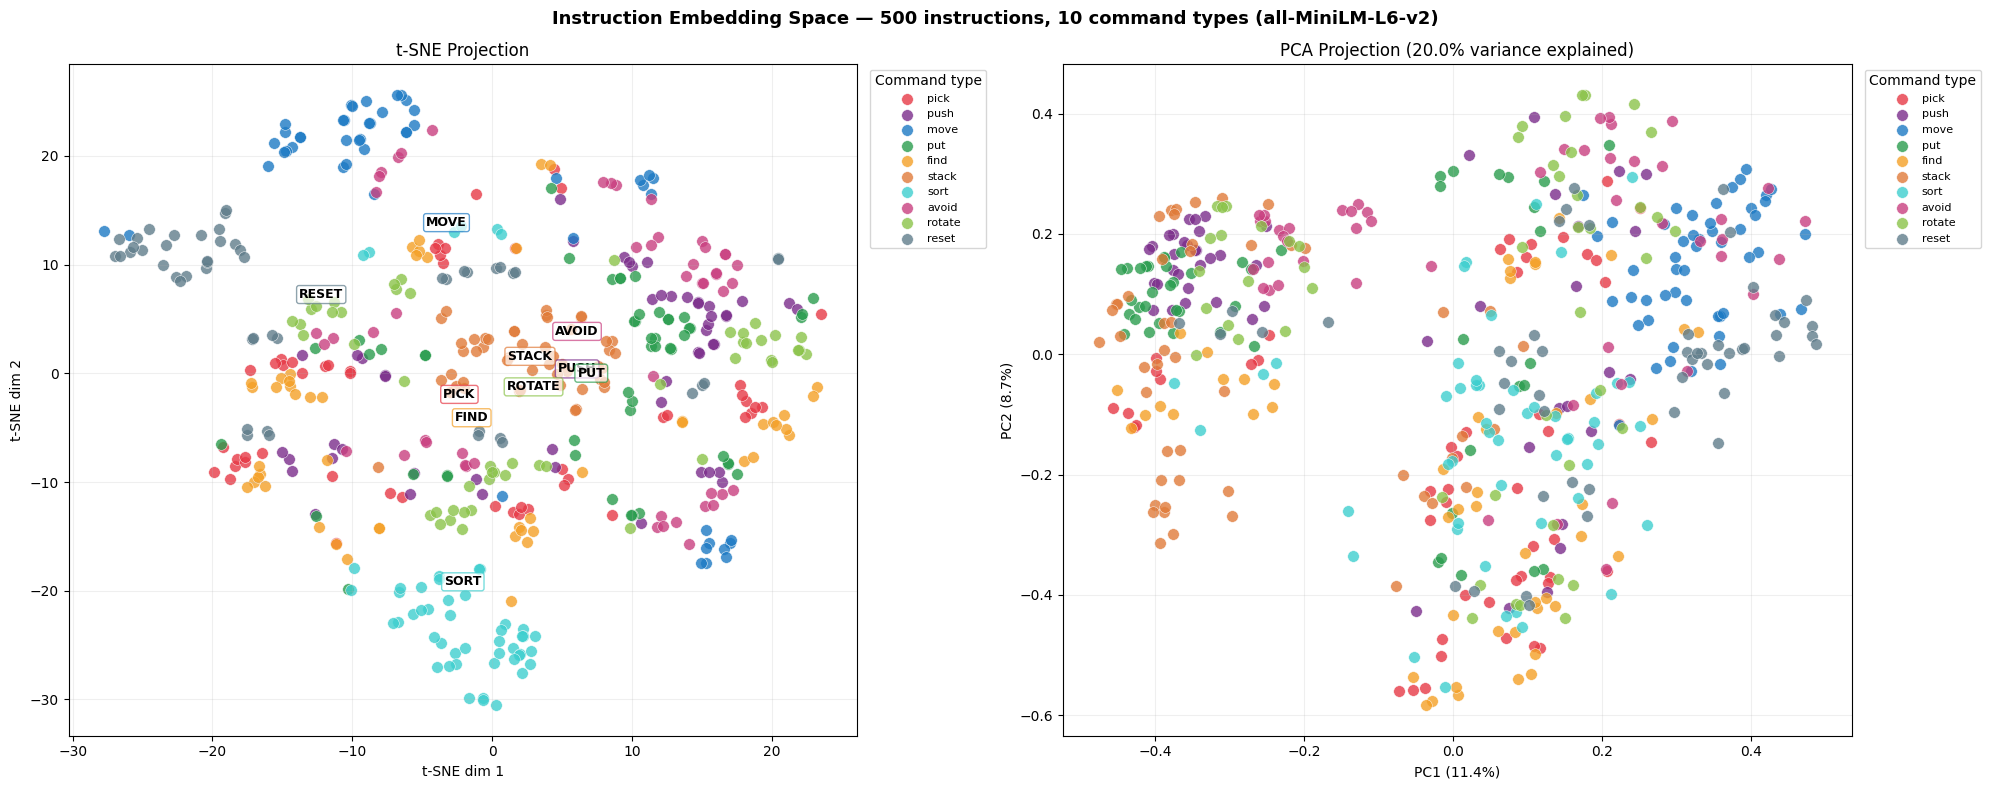

Saved: combined_visualization_500.png


In [23]:
# ==================== CELL 11: t-SNE + PCA VISUALIZATION ====================

palette = {
    "pick":   "#e63946",
    "push":   "#7b2d8b",
    "move":   "#1d7ac4",
    "put":    "#2a9d4e",
    "find":   "#f4a027",
    "stack":  "#e07b39",
    "sort":   "#3ecfcf",
    "avoid":  "#c94080",
    "rotate": "#8bc34a",
    "reset":  "#607d8b",
}

# t-SNE
tsne  = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
X_2d  = tsne.fit_transform(X)

# PCA
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
var1, var2 = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(
    "Instruction Embedding Space — 500 instructions, 10 command types (all-MiniLM-L6-v2)",
    fontsize=13, fontweight="bold"
)

for t, color in palette.items():
    mask = df["type"] == t
    # t-SNE
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, label=t, s=70, alpha=0.80,
                    edgecolors="white", linewidths=0.4)
    # PCA
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=t, s=70, alpha=0.80,
                    edgecolors="white", linewidths=0.4)

# Annotate t-SNE cluster centers
for t, color in palette.items():
    idxs = df[df["type"] == t].index
    cx, cy = X_2d[idxs, 0].mean(), X_2d[idxs, 1].mean()
    axes[0].text(cx, cy, t.upper(), fontsize=9, fontweight="bold", ha="center",
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor=color))

axes[0].set_title("t-SNE Projection", fontsize=12)
axes[0].set_xlabel("t-SNE dim 1"); axes[0].set_ylabel("t-SNE dim 2")
axes[0].legend(title="Command type", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
axes[0].grid(True, alpha=0.2)

axes[1].set_title(f"PCA Projection ({var1+var2:.1f}% variance explained)", fontsize=12)
axes[1].set_xlabel(f"PC1 ({var1:.1f}%)"); axes[1].set_ylabel(f"PC2 ({var2:.1f}%)")
axes[1].legend(title="Command type", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("combined_visualization_500.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: combined_visualization_500.png")

In [24]:
# ==================== CELL 12: ROBUSTNESS TEST ====================
# Confirm safe prefixes don't shift embeddings (results from our earlier test)

robustness_pairs = [
    ("pick the red cube",  "please pick the red cube"),    # expected > 0.90
    ("pick the red cube",  "carefully pick the red cube"), # expected > 0.90
    ("move to the table",  "can you move to the table"),   # borderline ~0.85
]

print("── ROBUSTNESS (prefix stability) ──")
for a, b in robustness_pairs:
    sim = cosine_similarity([model.encode(a)], [model.encode(b)])[0][0]
    tag = "✅" if sim > 0.85 else "⚠️ borderline"
    print(f"  {tag} {sim:.4f} | '{a}' ↔ '{b}'")

print("\n✅ Week 4 NLP milestone complete.")
print(f"   Dataset  : {len(df)} instructions, {df['type'].nunique()} types")
print(f"   Outputs  : nlp_instructions_500.csv / .pkl / embeddings_500.npy")
print(f"   RL team  : embeddings = np.load('embeddings_500.npy')")

── ROBUSTNESS (prefix stability) ──
  ✅ 0.9428 | 'pick the red cube' ↔ 'please pick the red cube'
  ✅ 0.9322 | 'pick the red cube' ↔ 'carefully pick the red cube'
  ⚠️ borderline 0.8479 | 'move to the table' ↔ 'can you move to the table'

✅ Week 4 NLP milestone complete.
   Dataset  : 500 instructions, 10 types
   Outputs  : nlp_instructions_500.csv / .pkl / embeddings_500.npy
   RL team  : embeddings = np.load('embeddings_500.npy')
